The aim of this notebook is to demonstrate that `ft4ftirs` is capable of reproducing a spectrum generated by Bruker OPUS. For that, we will use `ft4ftirs` to open an OPUS file, extract the interferogram and the required processing parameters, and reconstruct its spectral intensity data. Then, the resulting spectrum will be compared against the spectrum reconstructed by OPUS, which is stored in the original file itself.

Additionally, the output of this process will be stored using the `fer` data structure, to demonstrate how this processing can be reported in a reproducible and traceable manner.

**Requirements:** `ft4ftirs`, `brukeropusreader`, `ferpy`, `numpy`, `pandas`, `matplotlib`.

In [1]:
%matplotlib inline
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from brukeropusreader import read_file

import ft4ftirs
from ft4ftirs.io.bruker_opus import BrukerOpusReader
from ft4ftirs.processing.pipeline import SpectralPipeline
from ft4ftirs.processing.scan_averaging import average_spectra

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

# Works whether the notebook is run from examples/ or from the repo root.
OPUS_FILE = next(p for p in [Path("example_opus.0"), Path("examples/example_opus.0")] if p.exists())
# with_suffix() requires a leading dot, so build the "-fer.json" name from the stem.
# Kept distinct from the walkthrough's example_opus.fer.json so the two do not overwrite
# each other.
FER_FILE = OPUS_FILE.with_name(OPUS_FILE.stem + "-fer.json")

print("ft4ftirs :", ft4ftirs.__version__)
print("loaded from:", Path(ft4ftirs.__file__).parent)
print("OPUS file:", OPUS_FILE.resolve())

ft4ftirs : 1.0.0
loaded from: C:\Users\805849\Documents\ft4ftir\ft4ftirs
OPUS file: C:\Users\805849\Documents\ft4ftir\examples\example_opus.0


---
## 1. What the OPUS file contains

An OPUS file is a container of named blocks: data arrays and parameter blocks. It stores both the
**raw interferogram** (`IgSm`) *and* **OPUS's own processed spectrum** (`ScSm`) — which is what
makes the comparison in §6 possible.

In [2]:
opus = read_file(str(OPUS_FILE))

rows = []
for k in opus.keys():
    v = opus[k]
    if isinstance(v, dict):
        rows.append((k, "parameter block", f"{len(v)} keys"))
    elif isinstance(v, str):
        rows.append((k, "text", f"{len(v)} chars"))
    elif hasattr(v, "__len__"):
        rows.append((k, "data array", f"{len(v)} points"))
    else:
        rows.append((k, type(v).__name__, ""))

print(pd.DataFrame(rows, columns=["block", "kind", "size"]).to_string(index=False))

                      block            kind        size
           Text Information            text   274 chars
                      Optik parameter block     14 keys
     Fourier Transformation parameter block      8 keys
                Acquisition parameter block     15 keys
                     Sample parameter block     11 keys
                       IgSm      data array 8132 points
        IgSm Data Parameter parameter block     12 keys
                       PhSm      data array 1024 points
                       ScSm      data array  856 points
                         AB      data array  856 points
            Instrument (Rf) parameter block     39 keys
                 Optik (Rf) parameter block     14 keys
           Acquisition (Rf) parameter block     15 keys
Fourier Transformation (Rf) parameter block      8 keys
                       IgRf      data array 8132 points
        IgRf Data Parameter parameter block     12 keys
        ScRf Data Parameter parameter block     

### 1.1 The parameter blocks in full

In [3]:
def show_block(name: str) -> None:
    block = opus.get(name)
    if not block:
        print(f"--- {name}: not present ---\n")
        return
    df = pd.DataFrame({"parameter": list(block.keys()),
                       "value": [block[k] for k in block]})
    print(f"--- {name} ---")
    print(df.to_string(index=False))
    print()

for blk in ["Fourier Transformation", "Instrument", "Acquisition", "Optik",
            "IgSm Data Parameter", "ScSm Data Parameter"]:
    show_block(blk)

--- Fourier Transformation ---
parameter   value
      APF      B3
      HFQ   400.0
      LFQ  7000.0
      NLI       0
      PHR    32.0
      PHZ      ML
      SPZ      NO
      ZFF       2

--- Instrument ---
parameter             value
      HFL        15799.6875
      LFL               0.0
      LWN        15799.6875
      ABP             52808
      SSP                 1
      ASG                 1
      ARG                 2
      ASS                80
      GFW                40
      GBW                40
      BFW                 0
      BBW                 0
      PKA               363
      PKL              2033
      PRA               342
      PRL              2033
      P2A                 1
      P2L                 1
      P2R                 1
      P2K                 1
      DAQ                 0
      AG2                 1
      HUM                 0
      SSM                 1
      RSN               791
      CRR                 0
      SRT     1674054045.26
   

### 1.2 The parameters that actually drive the processing

Two of Bruker's codes are counter-intuitive:

* **`HFQ`** holds the *lower* wavenumber bound and **`LFQ`** the *upper* one — the names refer to
  the filter type (high-pass / low-pass), not to the wavenumber.
* **`ZFF`** is the zero-filling factor. 

In [4]:
ft = opus.get("Fourier Transformation", {})
inst = opus.get("Instrument", {})
acq = opus.get("Acquisition", {})

KEY_PARAMS = [
    ("APF", ft.get("APF"),  "apodization function"),
    ("PHZ", ft.get("PHZ"),  "phase-correction mode"),
    ("PHR", ft.get("PHR"),  "phase resolution / cm^-1"),
    ("ZFF", ft.get("ZFF"),  "zero-filling factor"),
    ("HFQ", ft.get("HFQ"),  "LOWER wavenumber bound / cm^-1"),
    ("LFQ", ft.get("LFQ"),  "UPPER wavenumber bound / cm^-1"),
    ("HFL", inst.get("HFL"), "HeNe laser wavenumber / cm^-1"),
    ("ASG", inst.get("ASG"), "signal gain"),
    ("AQM", acq.get("AQM"),  "acquisition mode (DD = bidirectional)"),
    ("RES", acq.get("RES"),  "nominal resolution / cm^-1"),
    ("NSS", acq.get("NSS"),  "number of scans"),
]
print(pd.DataFrame(KEY_PARAMS, columns=["code", "value", "meaning"]).to_string(index=False))

code       value                               meaning
 APF          B3                  apodization function
 PHZ          ML                 phase-correction mode
 PHR        32.0              phase resolution / cm^-1
 ZFF           2                   zero-filling factor
 HFQ       400.0        LOWER wavenumber bound / cm^-1
 LFQ      7000.0        UPPER wavenumber bound / cm^-1
 HFL  15799.6875         HeNe laser wavenumber / cm^-1
 ASG           1                           signal gain
 AQM          DD acquisition mode (DD = bidirectional)
 RES        16.0            nominal resolution / cm^-1
 NSS          80                       number of scans


---
## 2. Load through `ft4ftirs`

Because `AQM = DD` (bidirectional), the `IgSm` block holds a forward and a backward scan
concatenated. The reader splits them and returns **both, unaveraged**, in `data["interferograms"]`.

That matters. The two directions carry different phase errors, so they have to be transformed and
phase-corrected independently.

In [5]:
data = BrukerOpusReader().load(OPUS_FILE)

interferograms   = data["interferograms"]
apodizer         = data["apodizer"]
phase_corrector  = data["phase_corrector"]
signal_gain      = data["signal_gain"]
zff_file         = data["zero_filling_factor"]

print(f"raw IgSm block      : {len(opus['IgSm'])} points")
print(f"scan directions     : {[ig.scan_direction.value for ig in interferograms]}")
for ig in interferograms:
    print(f"   {ig.scan_direction.value:<9s} {ig.n_points} points, ZPD @ {ig.zpd_index}")
print()
ig0 = interferograms[0]
print(f"laser wavenumber    : {ig0.laser_wavenumber:.4f} cm^-1")
print(f"OPD sampling step   : {ig0.dx:.3e} cm")
print(f"max OPD             : {ig0.max_opd:.5f} cm")
print(f"unapodized resolution: {ig0.unapodized_resolution:.3f} cm^-1")
print()
print(f"apodization window  : {apodizer.window.name}   (APF={ig0.metadata['apf_code']})")
print(f"phase corrector     : {type(phase_corrector).__name__} "
      f"(PHR={ig0.metadata['phase_resolution_cm']} cm^-1)")
print(f"zero-filling factor : {zff_file}   (ZFF)")
print(f"trim bounds         : {ig0.metadata['wn_min']} .. {ig0.metadata['wn_max']} cm^-1")

raw IgSm block      : 8132 points
scan directions     : ['forward', 'backward']
   forward   4066 points, ZPD @ 2033
   backward  4066 points, ZPD @ 2029

laser wavenumber    : 15799.6875 cm^-1
OPD sampling step   : 3.165e-05 cm
max OPD             : 0.06434 cm
unapodized resolution: 15.543 cm^-1

apodization window  : BlackmanHarris3Term   (APF=B3)
phase corrector     : MertzPhaseCorrector (PHR=32.0 cm^-1)
zero-filling factor : 2   (ZFF)
trim bounds         : 400.0 .. 7000.0 cm^-1


---
## 3. The two interferograms

`SpectralPipeline` centres each interferogram on its ZPD **in place**, so copies are kept here in
order to plot them as read. The backward scan has already been time-reversed by the reader so both
run in the same OPD direction.

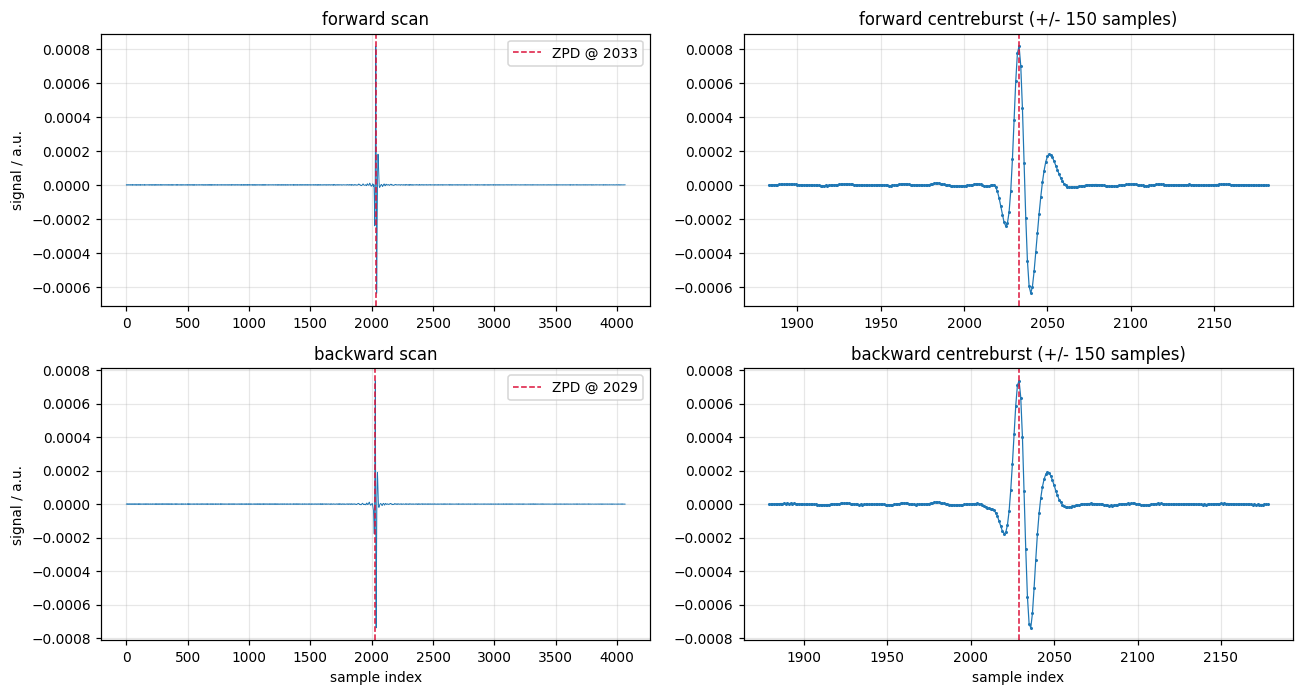

In [6]:
raw = [(ig.scan_direction.value, ig.x_index.copy(), ig.signal.copy(), ig.zpd_index)
       for ig in interferograms]

fig, axes = plt.subplots(len(raw), 2, figsize=(12, 3.2 * len(raw)))
axes = np.atleast_2d(axes)

for row, (name, x, y, zpd) in enumerate(raw):
    axes[row, 0].plot(x, y, lw=0.6)
    axes[row, 0].axvline(zpd, color="crimson", ls="--", lw=1, label=f"ZPD @ {zpd}")
    axes[row, 0].set_ylabel("signal / a.u."); axes[row, 0].legend()
    axes[row, 0].set_title(f"{name} scan")

    w = 150
    lo, hi = max(0, zpd - w), min(len(y), zpd + w)
    axes[row, 1].plot(x[lo:hi], y[lo:hi], lw=0.8, marker=".", ms=2)
    axes[row, 1].axvline(zpd, color="crimson", ls="--", lw=1)
    axes[row, 1].set_title(f"{name} centreburst (+/- {w} samples)")

for ax in axes[-1]:
    ax.set_xlabel("sample index")
fig.tight_layout(); plt.show()

---
## 4. Transform each direction, then average the **spectra**

In [7]:
# Re-load: the pipeline centres each interferogram on its ZPD *in place*, and §3 plotted
# the arrays as they were read.
d2 = BrukerOpusReader().load(OPUS_FILE)
pipeline = SpectralPipeline(d2["apodizer"], d2["phase_corrector"], zff_file)
per_direction = [pipeline(ig) for ig in d2["interferograms"]]
spec = average_spectra(per_direction)

print(f"zero-filling factor : {spec.metadata['zero_filling_factor']}   (the file's ZFF)")
print(f"FFT size            : {spec.metadata['fft_size']}")
print(f"spectra averaged    : {spec.metadata['n_spectra_averaged']}")
print(f"spectrum points     : {spec.n_points}")
print(f"point spacing       : {spec.point_spacing:.4f} cm^-1")
print(f"range               : {spec.wavenumber_range[0]:.2f} .. "
      f"{spec.wavenumber_range[1]:.2f} cm^-1")

zero-filling factor : 2   (the file's ZFF)
FFT size            : 4096
spectra averaged    : 2
spectrum points     : 856
point spacing       : 7.7147 cm^-1
range               : 401.16 .. 6997.22 cm^-1


---
## 5. `ft4ftirs` vs OPUS

The two carry different absolute scalings, so a single least-squares scale factor is fitted before
comparing shapes. That factor is reported — it is one constant, not a per-point correction.

In [8]:
sp = opus["ScSm Data Parameter"]
wn_opus = np.linspace(sp["FXV"], sp["LXV"], sp["NPT"])
sc_opus = np.asarray(opus["ScSm"][: sp["NPT"]], dtype=float)
# OPUS stores its axis DESCENDING (FXV = 6989 -> LXV = 393). Sort ascending: the mask and
# np.interp below both need an increasing axis, and without this the mask selects nothing.
order = np.argsort(wn_opus)
wn_opus, sc_opus = wn_opus[order], sc_opus[order]


def compare(spectrum, label, verbose=True):
    ours_i = spectrum.intensities / signal_gain
    lo = max(spectrum.wavenumbers[0], wn_opus[0])
    hi = min(spectrum.wavenumbers[-1], wn_opus[-1])
    m = (wn_opus >= lo) & (wn_opus <= hi)
    x, ref = wn_opus[m], sc_opus[m]
    ours = np.interp(x, spectrum.wavenumbers, ours_i)
    a = float(np.dot(ours, ref) / np.dot(ours, ours))
    res = ref - ours * a
    rms = 100 * np.sqrt(np.mean(res ** 2)) / np.ptp(ref)
    if verbose:
        print(f"{label:<34s} scale {a:.6g}   RMS {rms:.3f} %   "
              f"max {100 * np.max(np.abs(res)) / np.ptp(ref):.3f} %")
    return x, ref, ours * a, res, rms, a

print("versus the OPUS ScSm spectrum (RMS as % of its peak-to-peak):\n")
compare(per_direction[0], "forward only")
compare(per_direction[1], "backward only")
x_c, ref_c, ours_c, resid, rms_pct, scale = compare(spec, "AVERAGED SPECTRA")

versus the OPUS ScSm spectrum (RMS as % of its peak-to-peak):

forward only                       scale 0.999611   RMS 0.030 %   max 0.121 %
backward only                      scale 1.00022   RMS 0.032 %   max 0.136 %
AVERAGED SPECTRA                   scale 0.999915   RMS 0.012 %   max 0.092 %


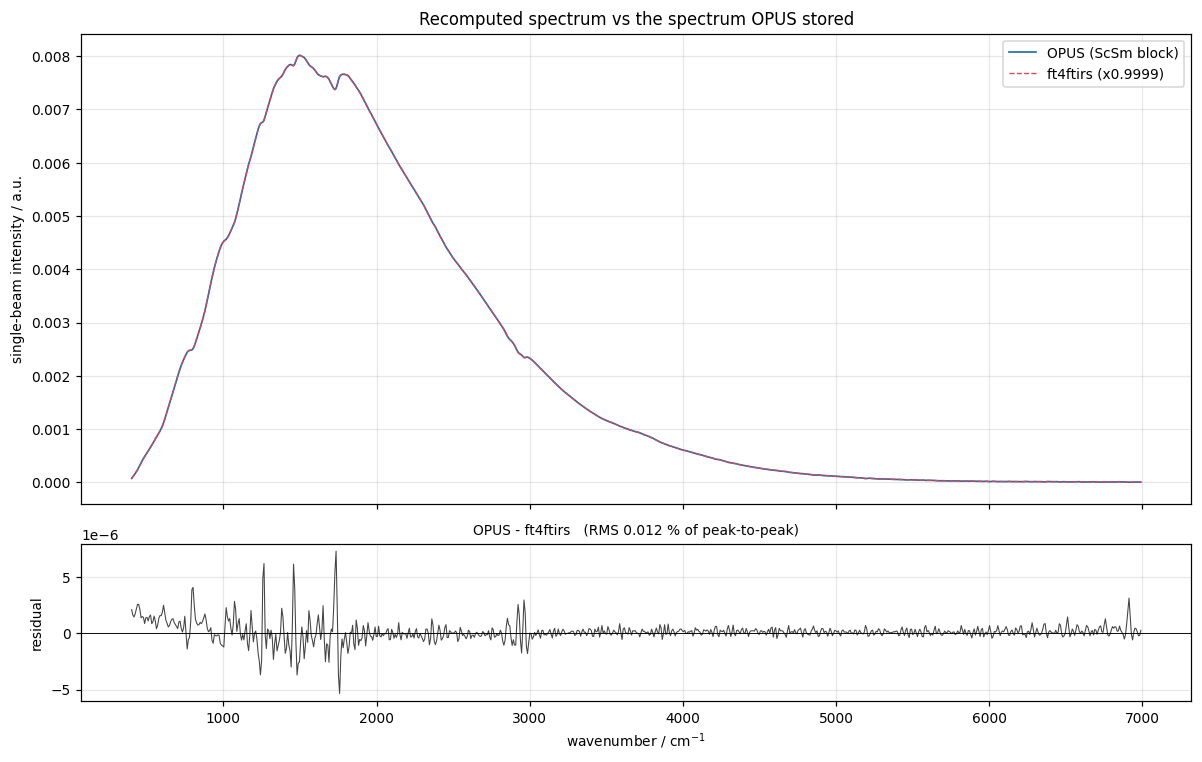

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(x_c, ref_c, lw=1.1, label="OPUS (ScSm block)", color="#1b6ca8")
ax1.plot(x_c, ours_c, lw=0.9, ls="--", label=f"ft4ftirs (x{scale:.4g})", color="#d1495b")
ax1.set_ylabel("single-beam intensity / a.u.")
ax1.set_title("Recomputed spectrum vs the spectrum OPUS stored")
ax1.legend()

ax2.plot(x_c, resid, lw=0.7, color="#444")
ax2.axhline(0, color="k", lw=0.6)
ax2.set_xlabel(r"wavenumber / cm$^{-1}$"); ax2.set_ylabel("residual")
ax2.set_title(f"OPUS - ft4ftirs   (RMS {rms_pct:.3f} % of peak-to-peak)", fontsize=9)

fig.tight_layout(); plt.show()

---
## 6. Export to FER

[FER](https://github.com/jongablop/fer) is a JSON structure for experimental results. Its core type,
`Measurement`, is recursive: a measurement's `Source` lists its `input_quantities`, which are
themselves `Measurement`s. Because we process each scan direction separately, the provenance
graph is genuinely three levels deep:

```
averaged spectrum (Measurement)
└── source = "average_spectra"
    └── input_quantities
        ├── forward spectrum (Measurement)
        │   └── source = "SpectralPipeline"   (its own window + phase arrays)
        │       └── input_quantities -> forward interferogram
        │                                └── source = the spectrometer  (terminal)
        └── backward spectrum (Measurement)
            └── source = "SpectralPipeline"
                └── input_quantities -> backward interferogram
                                         └── source = the spectrometer
```

Building that graph is `ft4ftirs.io.fer`: `write_fer()` writes it, `read_fer()` reads it back into
`Spectrum` and `Interferogram` objects. `ferpy` is an optional dependency of `ft4ftirs`
(`pip install ft4ftirs[fer]`); nothing else in the package imports it.

Conventions the module applies:

* **`Source`** carries what produced the value — the model and every quantity that propagates into
  the result. **`State`** carries conditions and categorical choices that do not. `ZFF` is an
  influence quantity, since the transform size is `next_power_of_two(wing × ZFF)`; `FFT size` and
  `Maximum retardation` are recorded beside it.
* **The apodization window and phase are stored as arrays**, not just names, so they can be checked
  without a `ft4ftirs` lookup table. Pass `applied_window=` / `applied_phase=` to record the arrays
  the pipeline really used; otherwise they are reconstructed at export and flagged as such in the
  document.
* **`standard_uncertainties` are emitted as empty arrays.** `ft4ftirs` does not compute
  uncertainties, and writing zeros would assert perfect knowledge in a GUM-shaped field.

In [10]:
from ft4ftirs.io.fer import read_fer, write_fer

optik = opus.get("Optik", {})
ig_params = opus.get("IgSm Data Parameter", {})

write_fer(
    FER_FILE,
    spec,                                       # the averaged spectrum: the root
    interferograms=d2["interferograms"],        # provenance, in the same order
    components=per_direction,                   # the spectra that were averaged
    apodizer=d2["apodizer"],
    phase_corrector=d2["phase_corrector"],
    instrument_name=f"{inst.get('INS', 'FT-IR spectrometer')} "
                    f"({optik.get('DTC', 'detector n/a')})",
    instrument_description=(
        f"serial={inst.get('SRN')}, beamsplitter={optik.get('BMS')}, "
        f"source={optik.get('SRC')}, aperture={optik.get('APT')}, "
        f"scans={acq.get('NSS')}, nominal resolution={acq.get('RES')} cm^-1, "
        f"acquired {ig_params.get('DAT')} {ig_params.get('TIM')}"
    ),
)

print(f"wrote {FER_FILE}  ({FER_FILE.stat().st_size / 1e6:.2f} MB)")

wrote example_opus-fer.json  (1.71 MB)


In [11]:
# What the document looks like, without dumping the arrays.
def outline(node, indent=0):
    pad = "   " * indent
    print(f"{pad}Measurement: {node['description']}")
    for st in node.get("state") or []:
        print(f"{pad}   state: {st['name']} = {st['description']}")
    for r in node.get("results") or []:
        print(f"{pad}   result: {r['name']} {r['quantities']} "
              f"lengths={[len(v) for v in r['values']]}")
    src = node.get("source")
    if src:
        print(f"{pad}   source: {src['name']}")
        for iq in src.get("influence_quantities") or []:
            lens = [len(v) for v in iq["values"]]
            shown = f"{iq['values'][0][0]:g} {iq['units'][0]}" if lens == [1] else f"arrays {lens}"
            print(f"{pad}      influence: {iq['name']}: {shown}")
        for inp in src.get("input_quantities") or []:
            outline(inp, indent + 2)

outline(json.load(open(FER_FILE, encoding="utf-8")))

Measurement: Single-beam spectrum, scan directions averaged
   state: Spectral quantity = SINGLE_BEAM
   result: Averaged single-beam spectrum ['Wavenumber', 'Spectral intensity'] lengths=[856, 856]
   source: ft4ftirs.processing.scan_averaging.average_spectra
      influence: Number of spectra averaged: 2 1
      Measurement: Single-beam spectrum from the forward scan
         state: Scan direction = forward
         state: Apodization window = BlackmanHarris3Term
         state: Phase correction = MertzPhaseCorrector
         state: ZPD finder = ArgmaxZpdFinder
         result: Single-beam spectrum ['Wavenumber', 'Spectral intensity'] lengths=[856, 856]
         source: ft4ftirs SpectralPipeline v1.0.0
            influence: Laser wavenumber: 15799.7 cm^-1
            influence: Maximum retardation: 2033 1
            influence: ZPD position: 2033 1
            influence: Zero-filling factor: 2 1
            influence: FFT size: 4096 1
            influence: Phase resolution: 32 cm^-

---
## 7. Read the FER file back and plot from it

Everything below comes **only** from the JSON file — nothing is reused from memory.

`read_fer()` returns a `FerDocument`: the root `Spectrum`, the per-direction `components`, every
`Interferogram` in the provenance graph, and the parsed ferpy `Measurement` for anything the wrapper
does not expose. Scalars and categorical states are mapped back into each object's `metadata`.

In [12]:
doc = read_fer(FER_FILE)

print("root spectrum  :", doc.spectrum.metadata["description"])
print("  quantity     :", doc.spectrum.quantity.name)
print("  points       :", doc.spectrum.n_points)
print("  produced by  :", doc.spectrum.metadata["source"])
print("  measurands   :", doc.measurement.measurands)
print()
print(f"components     : {len(doc.components)}")
for s in doc.components:
    print(f"   {s.metadata['description']}")
    print(f"      pipeline : {s.metadata['source']}")
    print(f"      settings : window={s.metadata.get('apodization_window')}, "
          f"phase={s.metadata.get('phase_corrector')}, "
          f"zpd_finder={s.metadata.get('zpd_finder')}")
    print(f"      numbers  : ZFF={s.metadata.get('zero_filling_factor')}, "
          f"fft_size={s.metadata.get('fft_size')}, "
          f"retardation={s.metadata.get('max_retardation_points')} samples")
print()
print(f"interferograms : {len(doc.interferograms)}")
for ig in doc.interferograms:
    print(f"   {ig.metadata['description']}  ({ig.n_points} points, "
          f"{ig.scan_direction.value})")
    print(f"      instrument: {ig.metadata['source']}")
print()

# and it round-trips
print("spectrum intensities :", np.allclose(doc.spectrum.intensities, spec.intensities))
for got, want in zip(doc.interferograms, d2["interferograms"]):
    print(f"{want.scan_direction.value:>8s} interferogram :",
          np.allclose(got.signal, want.signal))

root spectrum  : Single-beam spectrum, scan directions averaged
  quantity     : SINGLE_BEAM
  points       : 856
  produced by  : ft4ftirs.processing.scan_averaging.average_spectra
  measurands   : ['Spectral intensity']

components     : 2
   Single-beam spectrum from the forward scan
      pipeline : ft4ftirs SpectralPipeline v1.0.0
      settings : window=BlackmanHarris3Term, phase=MertzPhaseCorrector, zpd_finder=ArgmaxZpdFinder
      numbers  : ZFF=2.0, fft_size=4096.0, retardation=2033.0 samples
   Single-beam spectrum from the backward scan
      pipeline : ft4ftirs SpectralPipeline v1.0.0
      settings : window=BlackmanHarris3Term, phase=MertzPhaseCorrector, zpd_finder=ArgmaxZpdFinder
      numbers  : ZFF=2.0, fft_size=4096.0, retardation=2033.0 samples

interferograms : 2
   Forward interferogram from example_opus.0  (4066 points, forward)
      instrument: VERTEX 80V (RT-DLaTGS [Internal Pos.1])
   Backward interferogram from example_opus.0  (4066 points, backward)
      ins

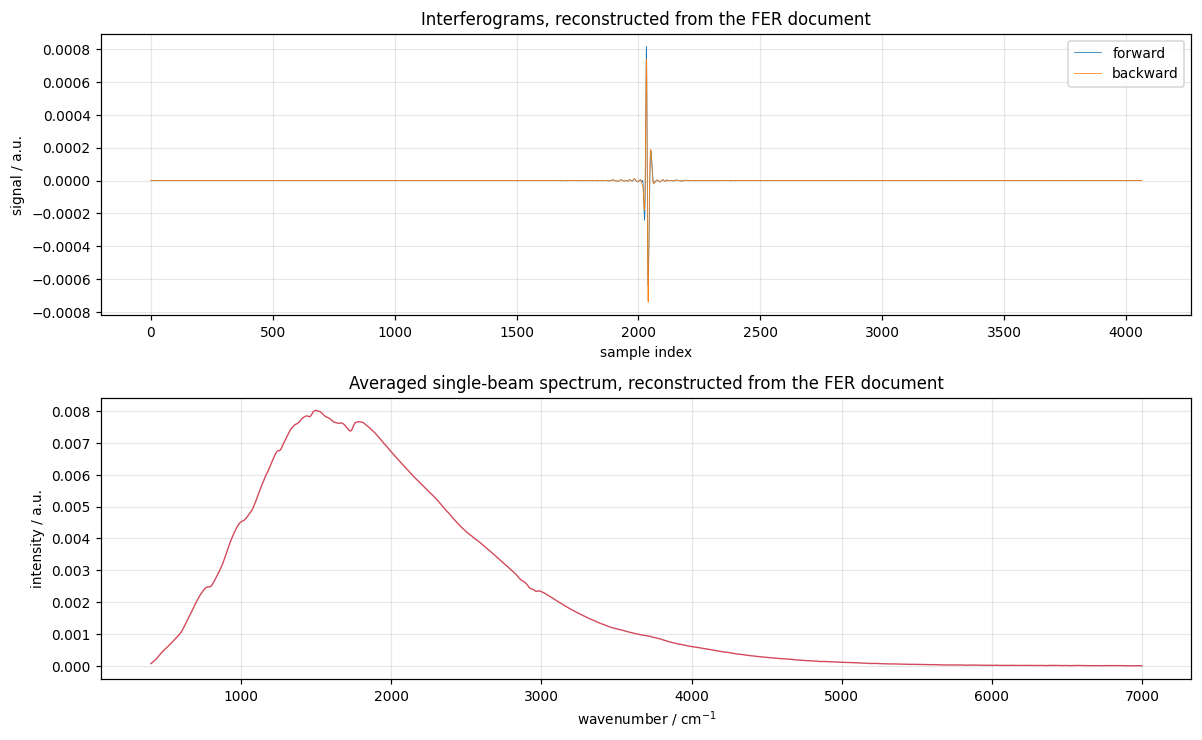

In [13]:
# Plotted straight off the objects read_fer() handed back.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.8))

for ig in doc.interferograms:
    ax1.plot(ig.x_index, ig.signal, lw=0.5, label=ig.scan_direction.value)
ax1.set_xlabel("sample index"); ax1.set_ylabel("signal / a.u."); ax1.legend()
ax1.set_title("Interferograms, reconstructed from the FER document")

ax2.plot(doc.spectrum.wavenumbers, doc.spectrum.intensities, lw=0.9, color="#d1495b")
ax2.set_xlabel(r"wavenumber / cm$^{-1}$"); ax2.set_ylabel("intensity / a.u.")
ax2.set_title("Averaged single-beam spectrum, reconstructed from the FER document")

fig.tight_layout(); plt.show()